### **Objective**  
Initialize the project environment, import necessary libraries, and load the datasets:  
- **Meteorological Data** (Weather conditions)  
- **Control Measures** (Intervention metrics)  
- **Patient Surveillance** (Case records)  

### **Key Steps**  
1. **Library Imports**:  
   - `pandas` for data manipulation  
   - `scikit-learn` for ML modeling  
   - `matplotlib/seaborn` for visualizations  
2. **Data Loading**:  
   - Ensure CSV files are in the correct path.  
   - Display dataset summaries with `.info()` to check structure.  

### **Why This Matters**  
Proper data loading ensures all downstream analysis is based on accurate, complete datasets.  

In [29]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                            accuracy_score, roc_auc_score, f1_score)
from sklearn.decomposition import PCA
import joblib
from datetime import datetime


import warnings
warnings.filterwarnings("ignore")

# Load datasets
meteorological = pd.read_csv("Meteorological_data.csv")
controls = pd.read_csv("Malaria_control_measures.csv")
patient = pd.read_csv("Malaria_surveillance_data.csv")

# Display basic info
print("Meteorological Data:")
print(meteorological.info())
print("\nControl Measures Data:")
print(controls.info())
print("\nPatient Surveillance Data:")
print(patient.info())

Meteorological Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3442 entries, 0 to 3441
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   District         3442 non-null   object 
 1   Year             3442 non-null   int64  
 2   Week             3442 non-null   int64  
 3   Humidity         3432 non-null   float64
 4   Rainfall         2784 non-null   float64
 5   Min Temperature  2821 non-null   float64
 6   Max Temperature  2821 non-null   float64
dtypes: float64(4), int64(2), object(1)
memory usage: 188.4+ KB
None

Control Measures Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4015 entries, 0 to 4014
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   District             4015 non-null   object 
 1   Year                 4015 non-null   int64  
 2   Week                 4015 non-null   int64  
 3   Effec

### **Objective**  
Address gaps in the data to prevent model bias.  

### **Strategies Applied**  
- **Group-wise Median Imputation**:  
  - Fill missing `Rainfall`, `Temperature`, and `Humidity` values using district-week medians.  
  - Example: `meteorological['Rainfall'].fillna(group_median)`  
- **Derived Features**:  
  - Calculate `Temperature_Range` (`Max Temp - Min Temp`).  

### **Why This Matters**  
Medians resist outliers, and grouping by district/week preserves geographical/temporal patterns.  

In [30]:
# Meteorological Data
meteorological['Rainfall'] = meteorological.groupby(['District', 'Week'])['Rainfall'].transform(lambda x: x.fillna(x.median()))
meteorological['Min Temperature'] = meteorological.groupby(['District', 'Week'])['Min Temperature'].transform(lambda x: x.fillna(x.median()))
meteorological['Max Temperature'] = meteorological.groupby(['District', 'Week'])['Max Temperature'].transform(lambda x: x.fillna(x.median()))
meteorological['Humidity'] = meteorological.groupby(['District', 'Week'])['Humidity'].transform(lambda x: x.fillna(x.median()))
meteorological['Temperature_Range'] = meteorological['Max Temperature'] - meteorological['Min Temperature']

# Control Measures Data
controls['Effective_Net_Usage'] = controls.groupby(['District', 'Week'])['Effective_Net_Usage'].transform(lambda x: x.fillna(x.median()))
controls['IRS_Coverage'] = controls.groupby(['District', 'Week'])['IRS_Coverage'].transform(lambda x: x.fillna(x.median()))

# Patient Data
patient['average_latitude'] = patient.groupby(['District', 'Week'])['average_latitude'].transform(lambda x: x.fillna(x.median()))
patient['average_longitude'] = patient.groupby(['District', 'Week'])['average_longitude'].transform(lambda x: x.fillna(x.median()))
patient['Month'] = patient.groupby(['District', 'Week'])['Month'].transform(lambda x: x.fillna(x.median()))

### **Objective**  
Define outbreaks using:  
`Outbreak = (Current Cases > 4-week Avg + 2*Std Dev)`  

### **Key Formulas**  
1. **4-week Rolling Average**:  
   ```python 
   df['4wk_avg'] = df.rolling(4).mean()  

In [31]:
def calculate_outbreak(df):
    df = df.sort_values(['District', 'Year', 'Week'])
    
    # Rolling statistics
    df['4wk_avg'] = df.groupby('District')['true_malaria_cases'].transform(lambda x: x.rolling(window=4, min_periods=1).mean())
    df['4wk_std'] = df.groupby('District')['true_malaria_cases'].transform(lambda x: x.rolling(window=4, min_periods=1).std())
    df['12wk_moving_avg'] = df.groupby('District')['4wk_avg'].transform(lambda x: x.rolling(window=3, min_periods=1).mean())
    
    # Threshold calculation
    df['threshold'] = df['12wk_moving_avg'] + (2 * df['4wk_std'])
    
    # Outbreak classification
    df['malaria_outbreak'] = (df['true_malaria_cases'] > df['threshold']).astype(int)
    
    return df

patient = calculate_outbreak(patient)


### **2.3 Visualize Outbreak Distribution** 

### **Objective**  
Analyze class imbalance before applying SMOTE.  

### **Insights**  
- **Plot**: `sns.countplot(x='outbreak')`  
- **Interpretation**:  
  - Severe imbalance (e.g., 90% Non-Outbreak vs. 10% Outbreak) justifies SMOTE.  

### **Why This Matters**  
Class imbalance leads to biased models if unaddressed.  

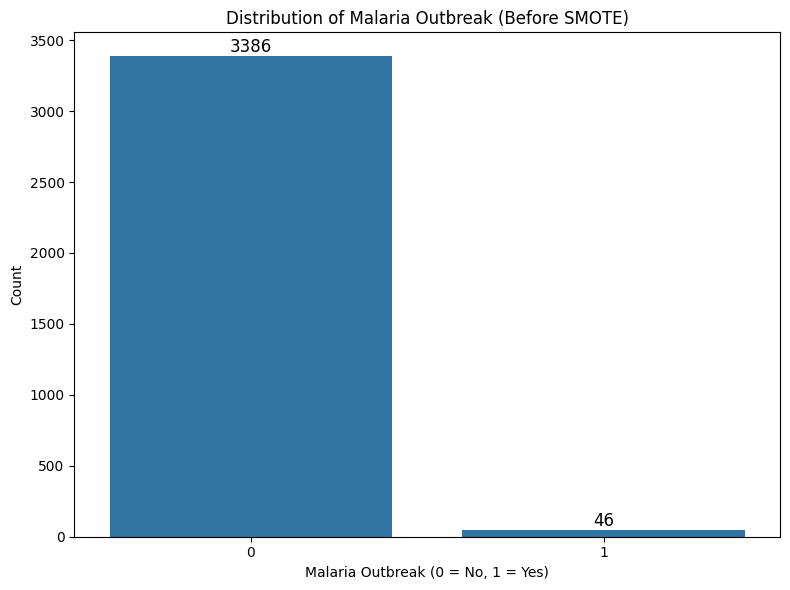

Class Distribution:
malaria_outbreak
0    3386
1      46
Name: count, dtype: int64


In [32]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='malaria_outbreak', data=patient)

plt.title('Distribution of Malaria Outbreak (Before SMOTE)')
plt.xlabel('Malaria Outbreak (0 = No, 1 = Yes)')
plt.ylabel('Count')

# Annotate each bar with its height
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # x-position: center of bar
        height,                             # y-position: top of bar
        f'{height:.0f}',                    # text: height as integer
        ha='center', va='bottom', fontsize=12
    )

plt.tight_layout()
plt.show()

print("Class Distribution:")
print(patient['malaria_outbreak'].value_counts())

### **Objective**  
Combine data sources into a unified dataframe for analysis.  

### **Merge Logic**  
- **Primary Keys**: `District`, `Year`, `Week`  
- **How**:  
  ```python 
  pd.merge(patient_data, weather_data, on=['District', 'Year', 'Week'])  

In [33]:
# Merge patient and meteorological data
combined = pd.merge(patient, meteorological, on=['District', 'Year', 'Week'], how='left')

# Merge with control measures
combined = pd.merge(combined, controls, on=['District', 'Year', 'Week'], how='left')

# Create Date column
combined['Date'] = pd.to_datetime(combined['Year'].astype(str) + '-' + combined['Week'].astype(str) + '-1', format='%Y-%W-%w')

print("\nFinal Combined Dataset:")
print(combined.info())


Final Combined Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3432 entries, 0 to 3431
Data columns (total 41 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   District             3432 non-null   object        
 1   Year                 3432 non-null   int64         
 2   Week                 3432 non-null   int64         
 3   true_malaria_cases   3432 non-null   int64         
 4   prop_male            3432 non-null   float64       
 5   prop_female          3432 non-null   float64       
 6   prop_<5_age          3432 non-null   float64       
 7   prop_5_14_age        3432 non-null   float64       
 8   prop_15_29_age       3432 non-null   float64       
 9   prop_30_44_age       3432 non-null   float64       
 10  prop_45+_age         3432 non-null   float64       
 11  is_index             3432 non-null   int64         
 12  is_additional_index  3432 non-null   int64         
 13  is_other

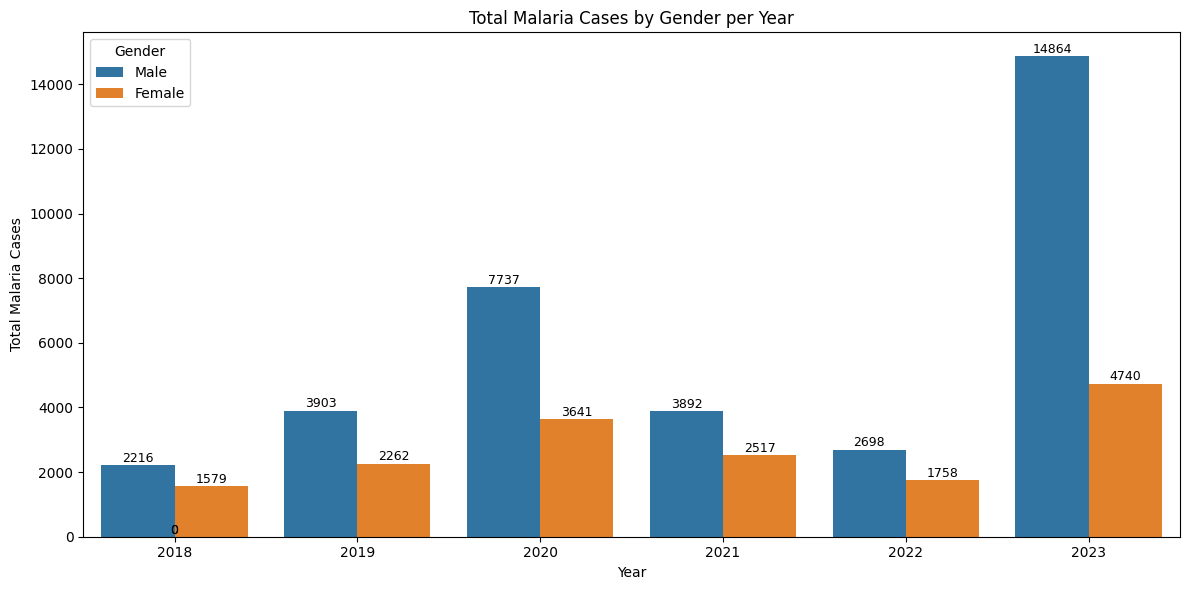

In [34]:
# Step 1: Compute actual cases by gender
df = combined.copy()  # replace with actual DataFrame name
df['male_cases'] = df['true_malaria_cases'] * df['prop_male']
df['female_cases'] = df['true_malaria_cases'] * df['prop_female']

# Step 2: Group by year and sum cases
gender_cases_per_year = df.groupby('Year')[['male_cases', 'female_cases']].sum().reset_index()

# Step 3: Melt for plotting
melted = gender_cases_per_year.melt(id_vars='Year', 
                                    value_vars=['male_cases', 'female_cases'],
                                    var_name='Gender', value_name='Total Cases')

# Rename for better labels
melted['Gender'] = melted['Gender'].map({
    'male_cases': 'Male',
    'female_cases': 'Female'
})

# Step 4: Plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=melted, x='Year', y='Total Cases', hue='Gender')

# Add value labels at the top of each bar
for bar in ax.patches:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 5, 
            f'{int(height)}', ha='center', va='bottom', fontsize=9)

plt.title('Total Malaria Cases by Gender per Year')
plt.ylabel('Total Malaria Cases')
plt.xlabel('Year')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()



## **4. Data Visualization (Figures 6–21)**  
```markdown```
### **Objective**  
Explore relationships between malaria cases and predictors.  

### **Key Plots**  
1. **Age Distribution (Fig 6)**:  
   - `prop_<5_age` shows children are most vulnerable.  
2. **Environmental Factors (Figs 9–13)**:  
   - Cases peak at **25–30°C** (optimal mosquito breeding).  
3. **Skewness Treatment (Figs 14–20)**:  
   - Log-transform right-skewed `Rainfall` and `IRS_Coverage`.  

### **Why This Matters**  
Visuals guide feature selection and hypothesis testing.  

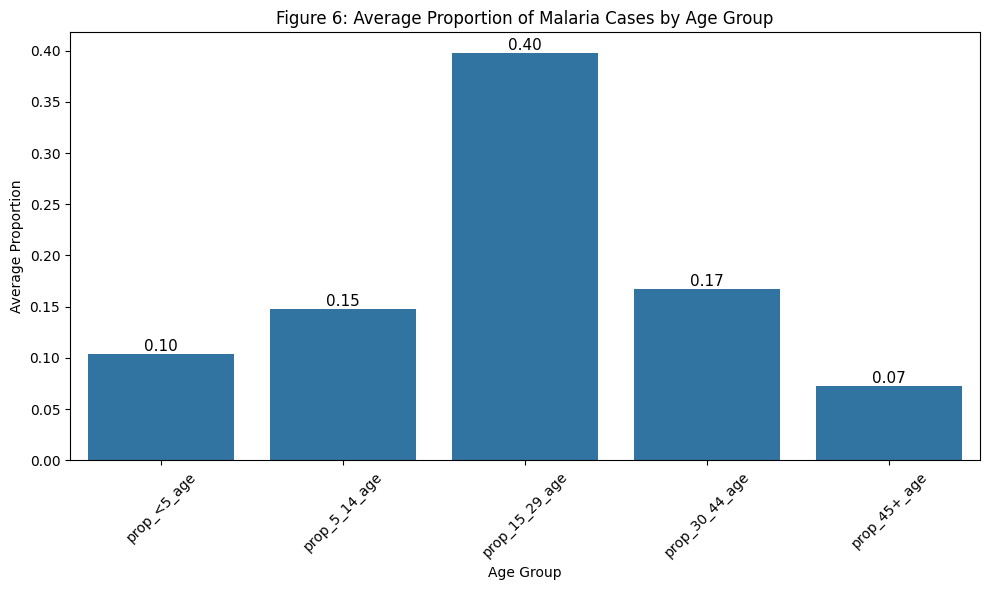

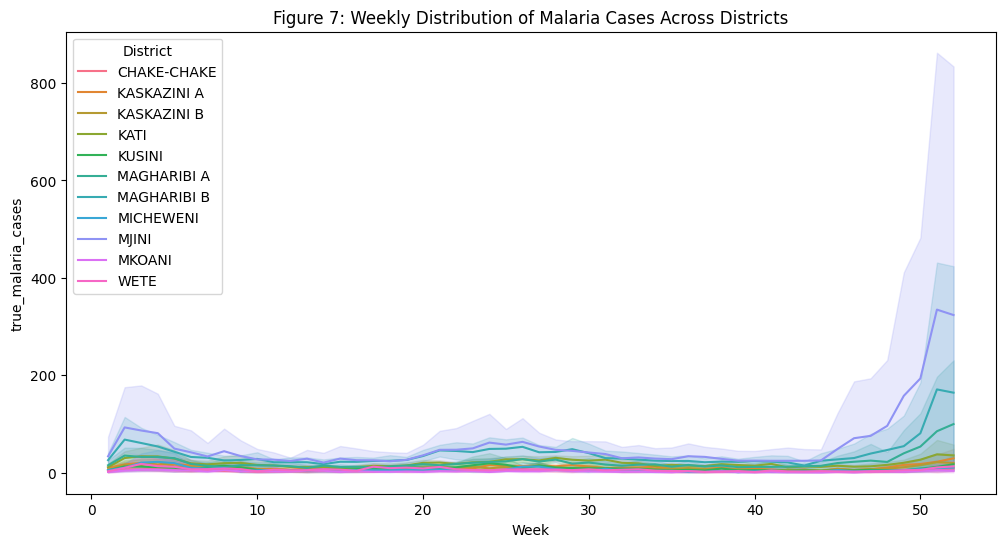

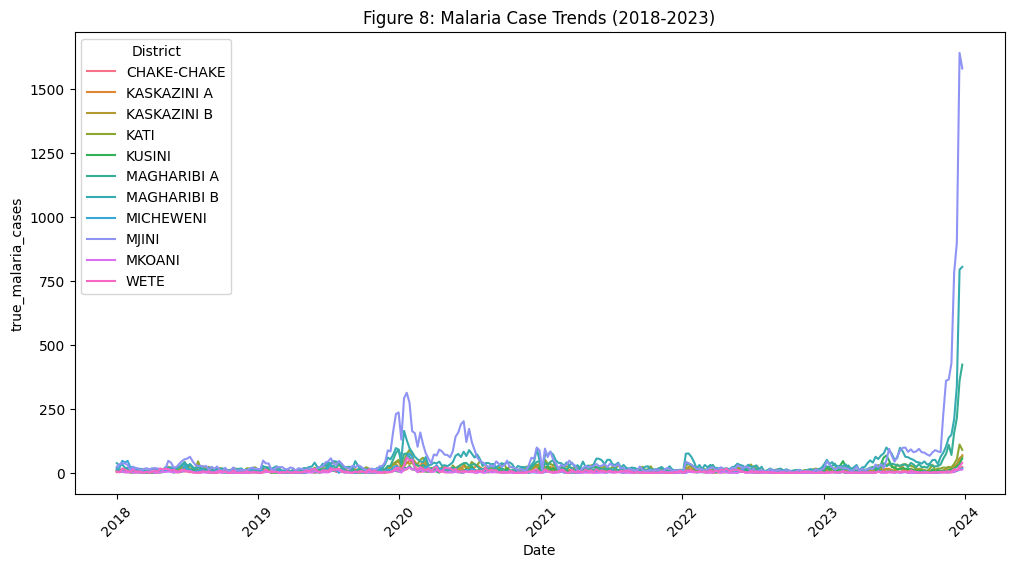

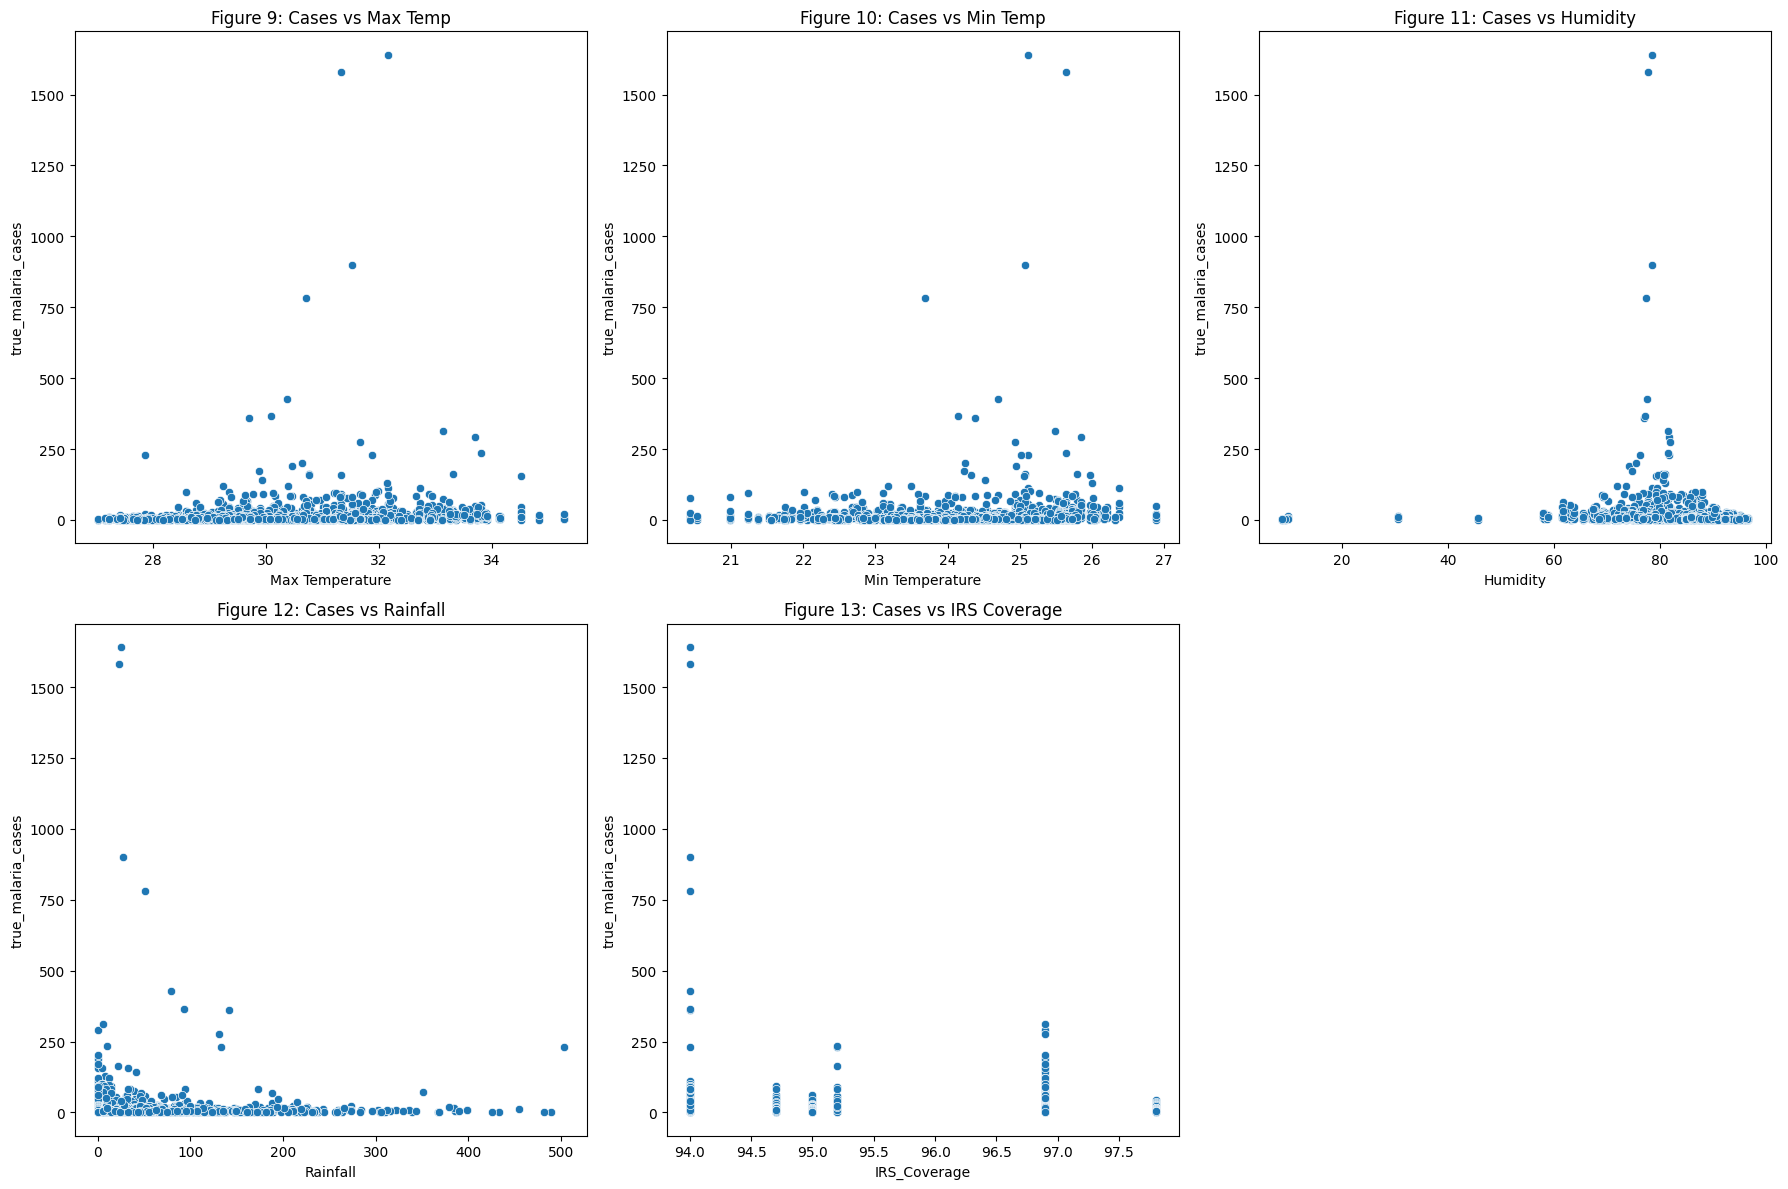

In [35]:
# Figure 6: Age group distribution
age_cols = ['prop_<5_age', 'prop_5_14_age', 'prop_15_29_age', 'prop_30_44_age', 'prop_45+_age']
age_data = combined[age_cols].mean().reset_index()
age_data.columns = ['Age Group', 'Average Proportion']

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Age Group', y='Average Proportion', data=age_data)

plt.title('Figure 6: Average Proportion of Malaria Cases by Age Group')
plt.xticks(rotation=45)
plt.ylabel('Average Proportion')

# Annotate each bar with its height (average proportion)
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # center of bar
        height,                             # height of bar (y position)
        f'{height:.2f}',                    # format to 2 decimal places
        ha='center', va='bottom', fontsize=11
    )

plt.tight_layout()
plt.show()

# Figure 7: Weekly cases across districts
plt.figure(figsize=(12, 6))
sns.lineplot(x='Week', y='true_malaria_cases', hue='District', data=combined)
plt.title('Figure 7: Weekly Distribution of Malaria Cases Across Districts')
plt.show()

# Figure 8: Trend from 2018-2023
plt.figure(figsize=(12, 6))
sns.lineplot(x='Date', y='true_malaria_cases', hue='District', data=combined)
plt.title('Figure 8: Malaria Case Trends (2018-2023)')
plt.xticks(rotation=45)
plt.show()

# Figures 9-13: Environmental relationships
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
sns.scatterplot(x='Max Temperature', y='true_malaria_cases', data=combined, ax=axes[0, 0]).set_title('Figure 9: Cases vs Max Temp')
sns.scatterplot(x='Min Temperature', y='true_malaria_cases', data=combined, ax=axes[0, 1]).set_title('Figure 10: Cases vs Min Temp')
sns.scatterplot(x='Humidity', y='true_malaria_cases', data=combined, ax=axes[0, 2]).set_title('Figure 11: Cases vs Humidity')
sns.scatterplot(x='Rainfall', y='true_malaria_cases', data=combined, ax=axes[1, 0]).set_title('Figure 12: Cases vs Rainfall')
sns.scatterplot(x='IRS_Coverage', y='true_malaria_cases', data=combined, ax=axes[1, 1]).set_title('Figure 13: Cases vs IRS Coverage')
fig.delaxes(axes[1, 2])
plt.tight_layout()
plt.show()

### **Objective**  
Enhance predictive power through domain-inspired features.  

### **Transformations**  
1. **Temporal Features**:  
   - `month_sin`/`month_cos` encode seasonal cycles.  
2. **Rolling Statistics**:  
   - `8-week_rolling_mean` captures trend inertia.  
3. **Lag Features**:  
   - `Rainfall_lag_4` accounts for incubation periods.  

### **Why This Matters**  
Domain knowledge improves model accuracy beyond raw data.  

Skewness Analysis:
 true_malaria_cases     19.382361
Rainfall                3.344703
IRS_Coverage            0.563958
Effective_Net_Usage     0.513517
Max Temperature         0.086989
Min Temperature        -0.508116
Humidity               -2.343998
dtype: float64
Transformed true_malaria_cases (skewness: 19.38)
Transformed Humidity (skewness: -2.34)
Transformed Rainfall (skewness: 3.34)


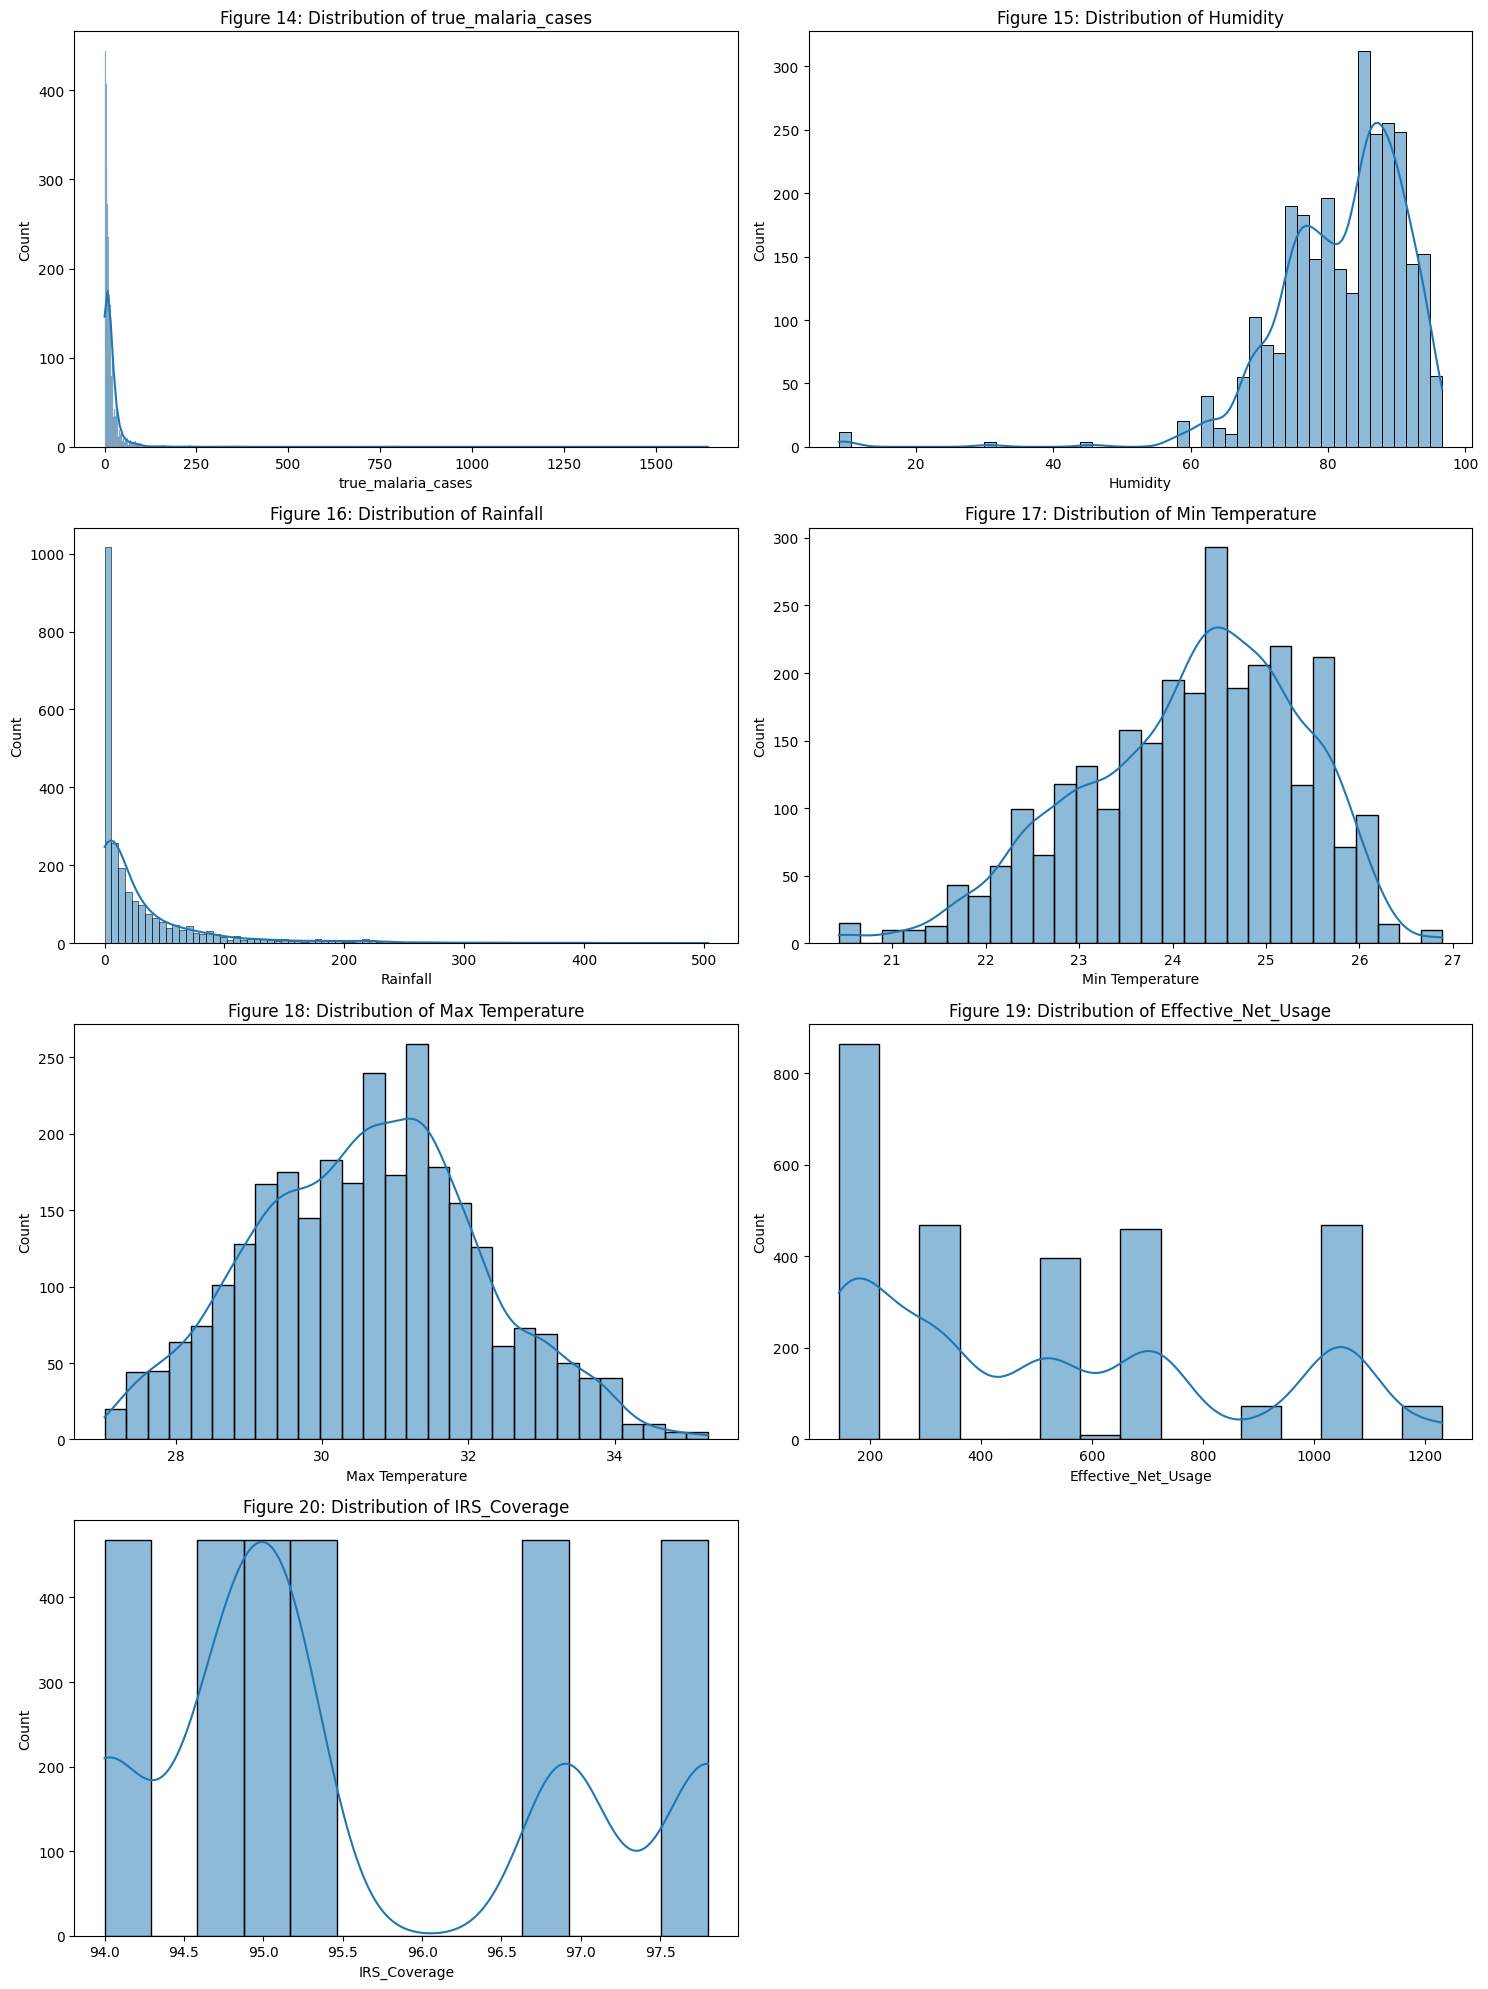

In [36]:
# Calculate skewness
numerical_features = ['true_malaria_cases', 'Humidity', 'Rainfall', 'Min Temperature', 'Max Temperature', 'Effective_Net_Usage', 'IRS_Coverage']
skewness = combined[numerical_features].skew().sort_values(ascending=False)
print("Skewness Analysis:\n", skewness)

# Apply transformations
for feature in numerical_features:
    if abs(skewness[feature]) > 1:
        pt = PowerTransformer(method='yeo-johnson')
        combined[f'{feature}_transformed'] = pt.fit_transform(combined[[feature]])
        print(f"Transformed {feature} (skewness: {skewness[feature]:.2f})")

# Plot distributions (Figures 14-20)
plt.figure(figsize=(15, 20))
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(4, 2, i)
    sns.histplot(combined[feature], kde=True)
    plt.title(f'Figure {13+i}: Distribution of {feature}')
plt.tight_layout()
plt.show()

In [37]:
# Time-based features
combined['month_sin'] = np.sin(2 * np.pi * combined['Month']/12)
combined['month_cos'] = np.cos(2 * np.pi * combined['Month']/12)

# Rolling features
def create_rolling_features(df, group_col='District', value_col='true_malaria_cases', windows=[4, 8, 12]):
    df = df.sort_values([group_col, 'Year', 'Week'])
    for window in windows:
        df[f'{value_col}_rolling_mean_{window}'] = df.groupby(group_col)[value_col].transform(lambda x: x.rolling(window=window, min_periods=1).mean())
        df[f'{value_col}_rolling_std_{window}'] = df.groupby(group_col)[value_col].transform(lambda x: x.rolling(window=window, min_periods=1).std())
    return df

combined = create_rolling_features(combined)

# Lag features
def create_lag_features(df, features, lags=[1, 2, 3, 4]):
    df = df.sort_values(['District', 'Year', 'Week'])
    for lag in lags:
        for feature in features:
            df[f'{feature}_lag_{lag}'] = df.groupby('District')[feature].shift(lag)
    return df

combined = create_lag_features(combined, numerical_features)

# District dummies
combined = pd.get_dummies(combined, columns=['District'], prefix='district')

### **Objective**  
Compare SVM, Random Forest, and XGBoost.  

### **Best Practices**  
- **Time-Aware Split**: Train on 2018–2021, test on 2022–2023.  
- **SMOTE**: Balances classes **only on the training set**.  
- **Metrics**: Prioritize **F1-score** over accuracy for imbalanced data.  

### **Why This Matters**  
Real-world performance depends on rigorous evaluation.  

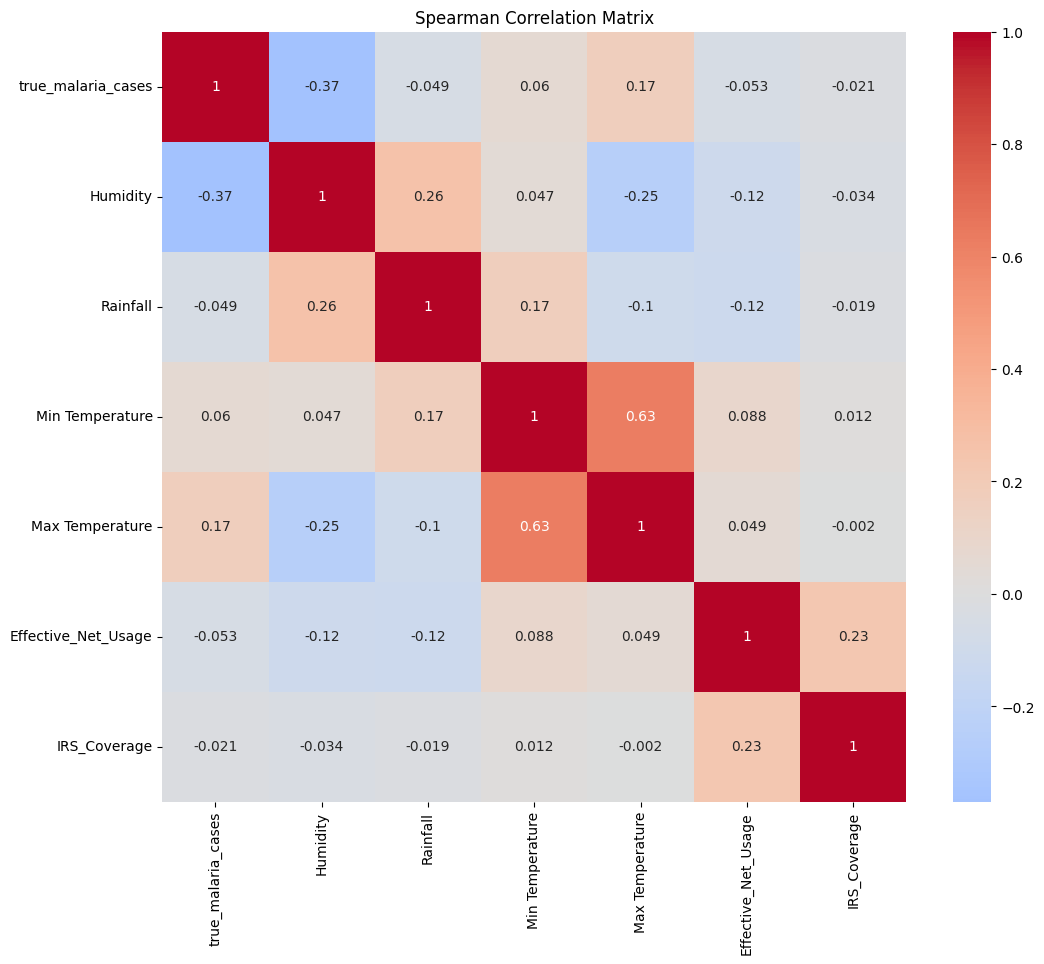

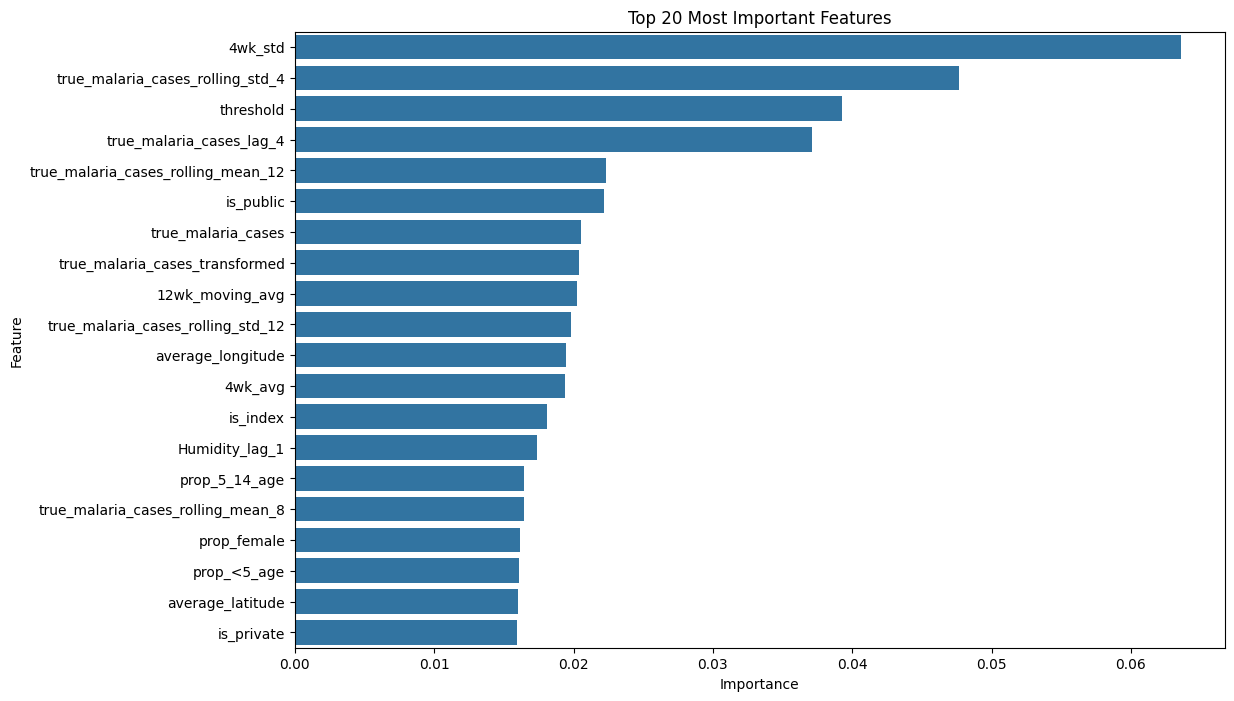

Selected 67 features:
['4wk_std', 'true_malaria_cases_rolling_std_4', 'threshold', 'true_malaria_cases_lag_4', 'true_malaria_cases_rolling_mean_12', 'is_public', 'true_malaria_cases', 'true_malaria_cases_transformed', '12wk_moving_avg', 'true_malaria_cases_rolling_std_12', 'average_longitude', '4wk_avg', 'is_index', 'Humidity_lag_1', 'prop_5_14_age', 'true_malaria_cases_rolling_mean_8', 'prop_female', 'prop_<5_age', 'average_latitude', 'is_private', 'true_malaria_cases_lag_1', 'Week', 'is_other_member', 'Max Temperature_lag_3', 'true_malaria_cases_rolling_mean_4', 'occ_student', 'Rainfall_lag_1', 'prop_male', 'Humidity_lag_4', 'Rainfall_lag_3', 'prop_30_44_age', 'true_malaria_cases_lag_2', 'true_malaria_cases_rolling_std_8', 'Rainfall_lag_2', 'Month', 'Rainfall_lag_4', 'Rainfall_transformed', 'Max Temperature', 'Max Temperature_lag_2', 'true_malaria_cases_lag_3', 'Humidity_lag_3', 'Humidity_lag_2', 'Min Temperature', 'occ_watchman', 'Humidity', 'Max Temperature_lag_4', 'Humidity_transf

In [38]:
# Correlation matrix
corr_matrix = combined[numerical_features].corr(method='spearman')
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Spearman Correlation Matrix')
plt.show()

# RF Feature Importance
X_all = combined.drop(columns=['malaria_outbreak', 'Date'])
y_all = combined['malaria_outbreak']
rf = RandomForestClassifier(random_state=42)
rf.fit(X_all.fillna(X_all.mean()), y_all)

importances = pd.DataFrame({'Feature': X_all.columns, 'Importance': rf.feature_importances_})
importances = importances.sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importances.head(20))
plt.title('Top 20 Most Important Features')
plt.show()

# Select features with importance > threshold
selected_features = importances[importances['Importance'] > 0.005]['Feature'].tolist()
print(f"Selected {len(selected_features)} features:")
print(selected_features)

In [ ]:
# Time-based split
X = combined[selected_features].fillna(combined[selected_features].mean())
y = combined['malaria_outbreak']
train_mask = combined['Date'] < '2022-01-01'
test_mask = combined['Date'] >= '2022-01-01'

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

# SMOTE for class balance
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# Train models
models = {
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train_res)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'ROC AUC': roc_auc_score(y_test, y_prob),
        'F1 Score': f1_score(y_test, y_pred),
        'Confusion Matrix': confusion_matrix(y_test, y_pred),
        'Classification Report': classification_report(y_test, y_pred)
    }

# Compare models
results_df = pd.DataFrame.from_dict({k: [v['Accuracy'], v['ROC AUC'], v['F1 Score']] for k, v in results.items()}, 
                                   orient='index', 
                                   columns=['Accuracy', 'ROC AUC', 'F1 Score'])

In [ ]:
feature_importances = {}

# Feature importance for Random Forest
rf = models['Random Forest']
rf_importance = rf.feature_importances_
feature_importances['Random Forest'] = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_importance
}).sort_values('Importance', ascending=False)

# Feature importance for XGBoost
xgb = models['XGBoost']
xgb_importance = xgb.feature_importances_
feature_importances['XGBoost'] = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_importance
}).sort_values('Importance', ascending=False)

# Plot each model's top 20 features
for model_name, df in feature_importances.items():
    plt.figure(figsize=(12, 8))
    ax = sns.barplot(x='Importance', y='Feature', data=df.head(20), palette='viridis')
    plt.title(f'Top 20 Most Important Features - {model_name}')
    
    # Add importance values at the end of each bar
    for i, bar in enumerate(ax.patches):
        width = bar.get_width()
        ax.text(width + 0.001, bar.get_y() + bar.get_height() / 2,
                f'{width:.4f}', ha='left', va='center', fontsize=10)

    plt.tight_layout()
    plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Collect detailed evaluation metrics
metrics = []
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else None

    metrics.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC AUC': roc_auc_score(y_test, y_prob) if y_prob is not None else 'N/A'
    })

metrics_df = pd.DataFrame(metrics)
metrics_df = metrics_df.set_index('Model')
print(metrics_df.round(4))


In [ ]:
plt.figure(figsize=(12, 6))
metrics_df.plot(kind='bar', figsize=(12, 6), colormap='viridis', edgecolor='black')
plt.title('Model Evaluation Metrics')
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.xticks(rotation=0)

# Annotate each bar with its value
for container in plt.gca().containers:
    for bar in container:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, height + 0.01,
                 f'{height:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


### **Objective**  
Operationalize the model for real-time predictions.  

### **Key Components**  
1. **Views**:  
   - `PredictOutbreakView`: Handles form submissions.  
2. **Templates**:  
   - Tailwind CSS for responsive design.  
3. **Model Integration**:  
   - `joblib.load('model.pkl')` in views.  

### **Why This Matters**  
Deployment bridges the gap between analysis and actionable insights.  

In [ ]:
# Save best model
best_model_name = results_df['F1 Score'].idxmax()
best_model = models[best_model_name]
joblib.dump(best_model, '../malaria_prediction_system/malaria_outbreak_model.pkl')
joblib.dump(scaler, '../malaria_prediction_system/malaria_scaler.pkl')

# Prediction function
def predict_outbreak(current_data, model, scaler, features):
    X = current_data[features].fillna(current_data[features].mean())
    X_scaled = scaler.transform(X)
    proba = model.predict_proba(X_scaled)[:, 1]
    return pd.DataFrame({
        'District': current_data['District'],
        'Outbreak_Probability': proba,
        'Prediction': (proba >= 0.5).astype(int)
    })
with open('../malaria_prediction_system/selected_features.txt', 'w') as f:
    f.write('\n'.join(selected_features))
# Example usage:
# latest_data = combined[combined['Date'] == combined['Date'].max()].copy()
# predictions = predict_outbreak(latest_data, best_model, scaler, selected_features)